# MDN-RNN Frame Prediction

MDN-RNN experiment for Moving MNIST frame forecasting.

The model consists of:
1. A VAE encoder/decoder to compress images to/from latent space
2. An MDN-RNN that predicts the next latent representation from sequence history
3. Decoding of predicted latents to generate future frames

This approach learns temporal dynamics in latent space using a mixture of Gaussians to model uncertainty in predictions.
The RNN processes sequences one frame at a time, maintaining history through its hidden state.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/jordanshivers/latent-video-forecasting.git"
REPO_DIRNAME = "latent-video-forecasting"
INSTALL_REQUIREMENTS = True

_current = Path.cwd().resolve()
REPO_ROOT = None
for _candidate in [_current, *_current.parents]:
    if (_candidate / "requirements.txt").exists() and (
        _candidate / "src" / "video_forecasting"
    ).is_dir():
        REPO_ROOT = _candidate
        break

if REPO_ROOT is None:
    _in_colab = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
    if _in_colab:
        _target = Path("/content") / REPO_DIRNAME
        if not _target.exists():
            subprocess.check_call(["git", "clone", GITHUB_REPO_URL, str(_target)])
        for _candidate in [_target, *_target.parents]:
            if (_candidate / "requirements.txt").exists() and (
                _candidate / "src" / "video_forecasting"
            ).is_dir():
                REPO_ROOT = _candidate
                break
    if REPO_ROOT is None:
        raise FileNotFoundError(
            f"Could not find repo root from {_current}. Run locally from the repo root/notebooks "
            "or set GITHUB_REPO_URL for standalone Colab execution."
        )

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

if INSTALL_REQUIREMENTS:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            str(REPO_ROOT / "requirements.txt"),
        ]
    )

from video_forecasting.runtime import get_data_dir, get_output_dir

DATA_DIR = get_data_dir(REPO_ROOT)
OUTPUT_DIR = get_output_dir("train_moving_mnist_mdn_rnn", REPO_ROOT)
print(f"Repo root: {REPO_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")

Repo root: /content/latent-video-forecasting
Data dir: /content/latent-video-forecasting/data
Output dir: /content/latent-video-forecasting/outputs/train_moving_mnist_mdn_rnn


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from pathlib import Path
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
from tqdm import tqdm
import imageio
import math
import warnings

warnings.filterwarnings("ignore")


from video_forecasting.runtime import get_device, set_seed

set_seed(42)
device = get_device(prefer_mps=True)
print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")

PyTorch version: 2.10.0+cu128
Selected device: cuda


In [3]:
from video_forecasting.datasets.moving_mnist import MovingMNISTDataset
from video_forecasting.models.vae import SequenceSpatialVAE as VAE
from video_forecasting.models.mdn_rnn import (
    MDNRNN,
    SequenceDataset,
    generate_rollout,
    mdn_loss,
    predict_next_frame,
    sample_from_mdn,
)
from video_forecasting.training import (
    FrameOnlyDataset,
    count_parameters,
    train_mdn_rnn_epoch,
    evaluate_mdn_rnn,
    train_vae_epoch,
)
from video_forecasting.visualization import (
    save_reconstruction_frame,
    set_output_dir,
    visualize_mdn_predictions as visualize_predictions,
)

set_output_dir(OUTPUT_DIR)

PosixPath('/content/latent-video-forecasting/outputs/train_moving_mnist_mdn_rnn')

## Load Moving MNIST Data

Load Moving MNIST datasets with train/test splits.

In [4]:
# Load Moving MNIST datasets
print("Loading Moving MNIST datasets...")
# Optional: Limit number of sequences for faster testing (None = use all)
max_sequences = (
    1000  # Set to a number (e.g., 1000) to limit dataset size for quick testing
)

train_dataset = MovingMNISTDataset(
    root=str(DATA_DIR),
    train=True,
    sequence_length=20,
    normalize=True,
    frame_separation=1,  # Not used for MDN-RNN, but required by dataset
    download=True,
    max_sequences=max_sequences,
)

test_dataset = MovingMNISTDataset(
    root=str(DATA_DIR),
    train=False,
    sequence_length=20,
    normalize=True,
    frame_separation=1,  # Not used for MDN-RNN, but required by dataset
    download=True,
    max_sequences=max_sequences,
)

print(f"\nMoving MNIST split:")
print(f"  Train: {len(train_dataset.sequences)} sequences")
print(f"  Test: {len(test_dataset.sequences)} sequences")

# # Extract normalization parameters from training set
# img_min, img_max = train_dataset.normalization_params

# print(f"\nMoving MNIST normalization params: min={img_min:.2f}, max={img_max:.2f}")
# print(f"Train samples: {len(train_dataset)}; test samples: {len(test_dataset)}")

Loading Moving MNIST datasets...
Loading Moving MNIST dataset (train=True)...
  Limited total to 1000 sequences (max_sequences=1000)

Dataset initialized:
  Split: train
  Total sequences: 800
  Frame separation: 1
  Total pairs: 15200
  Image size: 64x64
  Channels: 1 (grayscale)
Loading Moving MNIST dataset (train=False)...
  Limited total to 1000 sequences (max_sequences=1000)

Dataset initialized:
  Split: test
  Total sequences: 200
  Frame separation: 1
  Total pairs: 3800
  Image size: 64x64
  Channels: 1 (grayscale)

Moving MNIST split:
  Train: 800 sequences
  Test: 200 sequences


## Initialize VAE Model

In [5]:
# VAE parameters
latent_channels = 8
vae_hidden_dims = [32, 64, 128]
vae_beta = 1.0
vae_learning_rate = 3e-4
vae_num_epochs = 50

vae = VAE(
    in_channels=1,
    latent_channels=latent_channels,
    hidden_dims=vae_hidden_dims,
).to(device)

print(f"VAE parameters: {count_parameters(vae):,}")


VAE parameters: 458,464


In [6]:
# Create VAE training dataset (use all frames from both train and test)
max_height = max(train_dataset.target_height, test_dataset.target_height)
max_width = max(train_dataset.target_width, test_dataset.target_width)

vae_train_dataset = ConcatDataset(
    [
        FrameOnlyDataset(
            train_dataset, target_height=max_height, target_width=max_width
        ),
        FrameOnlyDataset(
            test_dataset, target_height=max_height, target_width=max_width
        ),
    ]
)

# Create data loaders
batch_size = 200
num_workers = 0

vae_train_loader = DataLoader(
    vae_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)

print(f"VAE training datasets created:")
print(f"  Moving MNIST: {len(vae_train_dataset)} frames")

VAE training datasets created:
  Moving MNIST: 20000 frames


Selected 1 sample images for reconstruction tracking (indices: [6500])
Training VAE.


Training VAE: 100%|██████████| 100/100 [00:02<00:00, 42.89it/s]


Epoch 5/50
  Total Loss: 132.588500
  Recon Loss: 115.955963
  KL Loss: 16.632537

  Saved reconstruction frame for epoch 5


Training VAE: 100%|██████████| 100/100 [00:02<00:00, 43.48it/s]


Epoch 10/50
  Total Loss: 120.827614
  Recon Loss: 101.252558
  KL Loss: 19.575057

  Saved reconstruction frame for epoch 10


...

Training VAE: 100%|██████████| 100/100 [00:02<00:00, 43.52it/s]


Epoch 45/50
  Total Loss: 96.805409
  Recon Loss: 62.661466
  KL Loss: 34.143943

  Saved reconstruction frame for epoch 45


Training VAE: 100%|██████████| 100/100 [00:02<00:00, 43.18it/s]


Epoch 50/50
  Total Loss: 95.271995
  Recon Loss: 60.047184
  KL Loss: 35.224812



  Saved reconstruction frame for epoch 50
VAE saved to /content/latent-video-forecasting/outputs/train_moving_mnist_mdn_rnn/vae_model_mdn_rnn.pt

Creating MP4 from 10 frames...
✓ MP4 saved to /content/latent-video-forecasting/outputs/train_moving_mnist_mdn_rnn/output_mp4s/vae_training_reconstructions_mdn_rnn.mp4


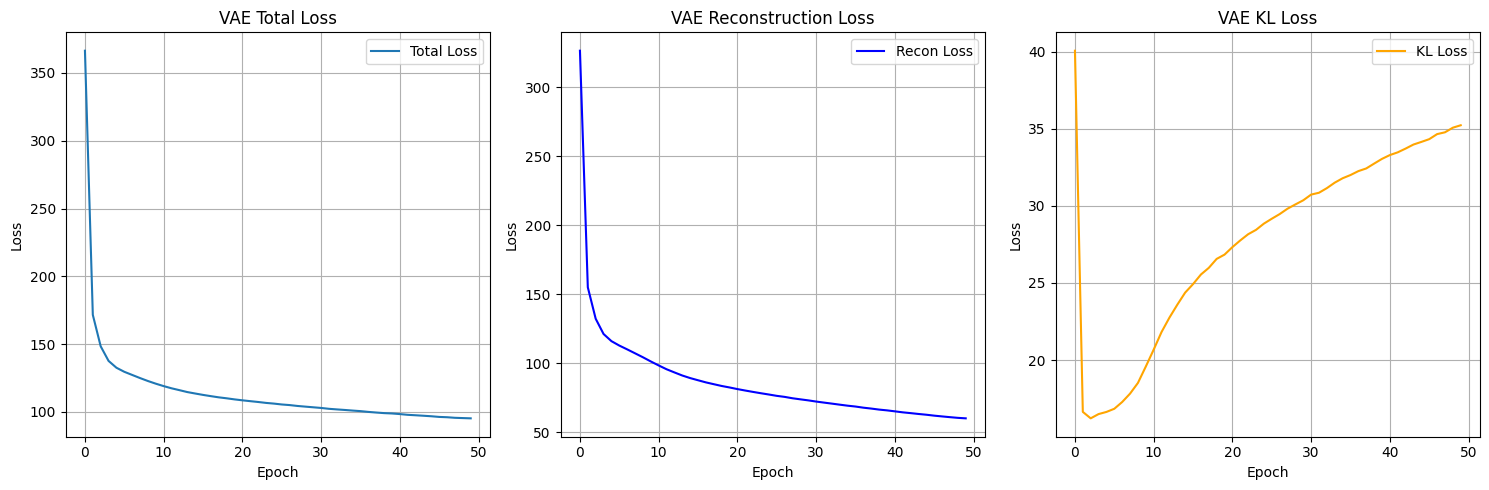

In [7]:
optimizer_vae = torch.optim.AdamW(
    vae.parameters(), lr=vae_learning_rate, weight_decay=1e-4
)
steps_per_epoch = len(vae_train_loader)
scheduler_lr_vae = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_vae,
    max_lr=vae_learning_rate,
    epochs=vae_num_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0,
)

vae_train_losses = []
vae_train_recon_losses = []
vae_train_kl_losses = []

load_vae = False
vae_path = OUTPUT_DIR / "vae_model_mdn_rnn.pt"

# Option to save reconstruction frames during training for MP4 creation
save_reconstruction_frames = True  # Set to True to generate MP4
reconstruction_frames_dir = OUTPUT_DIR / "vae_reconstruction_frames_mdn_rnn"
output_mp4_dir = OUTPUT_DIR / "output_mp4s"
if save_reconstruction_frames:
    reconstruction_frames_dir.mkdir(exist_ok=True)
    output_mp4_dir.mkdir(exist_ok=True)
    # Select sample images at the start (use fixed indices for consistency)
    num_sample_images = 1
    sample_indices = torch.randperm(len(vae_train_dataset))[:num_sample_images].tolist()
    print(
        f"Selected {num_sample_images} sample images for reconstruction tracking (indices: {sample_indices})"
    )

if load_vae and vae_path.exists():
    print(f"Loading VAE from {vae_path}...")
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("Loaded VAE.")
else:
    if load_vae:
        print(f"VAE checkpoint not found at {vae_path}; training now.")
    else:
        print("Training VAE.")

    for epoch in range(vae_num_epochs):
        recon_loss, kl_loss, loss = train_vae_epoch(
            vae, vae_train_loader, optimizer_vae, device, beta=vae_beta
        )
        vae_train_losses.append(loss)
        vae_train_recon_losses.append(recon_loss)
        vae_train_kl_losses.append(kl_loss)
        scheduler_lr_vae.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{vae_num_epochs}")
            print(f"  Total Loss: {loss:.6f}")
            print(f"  Recon Loss: {recon_loss:.6f}")
            print(f"  KL Loss: {kl_loss:.6f}")
            print()
            # Save reconstruction frame every 5 epochs
            if save_reconstruction_frames:
                save_reconstruction_frame(
                    vae,
                    vae_train_dataset,
                    sample_indices,
                    epoch,
                    reconstruction_frames_dir,
                    device,
                )
                print(f"  Saved reconstruction frame for epoch {epoch + 1}")

    # Save VAE
    torch.save(vae.state_dict(), vae_path)
    print(f"VAE saved to {vae_path}")

    # Create MP4 from saved frames
    if save_reconstruction_frames:
        frame_files = sorted(reconstruction_frames_dir.glob("epoch_*.png"))
        if len(frame_files) > 0:
            print(f"\nCreating MP4 from {len(frame_files)} frames...")
            images = []
            for frame_file in frame_files:
                images.append(imageio.imread(frame_file))
            mp4_path = output_mp4_dir / "vae_training_reconstructions_mdn_rnn.mp4"
            fps = 2  # 2 frames per second (0.5 seconds per frame)
            imageio.mimwrite(str(mp4_path), images, fps=fps, codec="libx264", quality=8)
            print(f"✓ MP4 saved to {mp4_path}")
        else:
            print("No frames found to create MP4")

# Plot training curves
if len(vae_train_losses) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].plot(vae_train_losses, label="Total Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("VAE Total Loss")
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(vae_train_recon_losses, label="Recon Loss", color="blue")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("VAE Reconstruction Loss")
    axes[1].legend()
    axes[1].grid(True)
    axes[2].plot(vae_train_kl_losses, label="KL Loss", color="orange")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].set_title("VAE KL Loss")
    axes[2].legend()
    axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "vae_training_curves_mdn_rnn.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

## Initialize MDN-RNN Model

First, we need to determine the latent dimension by encoding a sample frame.

In [8]:
# Determine latent dimension by encoding a sample
vae.eval()
with torch.no_grad():
    sample_frame = train_dataset.sequences[0][0]
    sample_tensor = torch.from_numpy(sample_frame).float().unsqueeze(0).to(device)
    sample_latent = vae.encode_to_latent(sample_tensor)
    latent_shape = sample_latent.shape  # [1, C, H, W]
    latent_dim = sample_latent.numel() // sample_latent.shape[0]  # Flattened dimension
    print(f"Latent shape: {latent_shape}")
    print(f"Latent dimension (flattened): {latent_dim}")

# MDN-RNN parameters
hidden_dim = 128
num_layers = 3
n_mixtures = 8
rnn_type = "gru"

# Create MDN-RNN model
mdn_rnn = MDNRNN(
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    n_mixtures=n_mixtures,
    rnn_type=rnn_type,
).to(device)

print(f"\nMDN-RNN parameters: {count_parameters(mdn_rnn):,}")
print(f"  Hidden dimension: {hidden_dim}")
print(f"  Number of layers: {num_layers}")
print(f"  Number of mixtures: {n_mixtures}")
print(f"  RNN type: {rnn_type}")
print(f"  Processing: Sequential (one frame at a time with hidden state)")

Latent shape: torch.Size([1, 8, 8, 8])
Latent dimension (flattened): 512

MDN-RNN parameters: 1,502,472
  Hidden dimension: 128
  Number of layers: 3
  Number of mixtures: 8
  RNN type: gru
  Processing: Sequential (one frame at a time with hidden state)


## Train MDN-RNN

Train the MDN-RNN to predict next latent representations with teacher forcing.

In [9]:
# Create sequence datasets
train_seq_dataset = SequenceDataset(train_dataset)
test_seq_dataset = SequenceDataset(test_dataset)

print(f"Sequence datasets created:")
print(f"  Train: {len(train_seq_dataset)} sequences")
print(f"  Test: {len(test_seq_dataset)} sequences")

# Create data loaders
mdn_batch_size = 200
mdn_train_loader = DataLoader(
    train_seq_dataset,
    batch_size=mdn_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)

mdn_test_loader = DataLoader(
    test_seq_dataset,
    batch_size=mdn_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)

Sequence datasets created:
  Train: 800 sequences
  Test: 200 sequences


VAE loaded for MDN-RNN training.
Training MDN-RNN.


Evaluating MDN-RNN: 100%|██████████| 1/1 [00:00<00:00,  6.01it/s]


Epoch 1/100 - Saved best model (val_loss: 459.318604)


Evaluating MDN-RNN: 100%|██████████| 1/1 [00:00<00:00,  6.03it/s]


Epoch 2/100 - Saved best model (val_loss: 327.016785)


...

Epoch 96/100 - Saved best model (val_loss: -420.372375)


Evaluating MDN-RNN: 100%|██████████| 1/1 [00:00<00:00,  6.14it/s]


Epoch 98/100 - Saved best model (val_loss: -421.634644)


Evaluating MDN-RNN: 100%|██████████| 1/1 [00:00<00:00,  6.03it/s]


Epoch 100/100 - Saved best model (val_loss: -421.997620)
Epoch 100/100
  Train Loss: -256.272659
  Val Loss: -421.997620

Training completed!
Best validation loss: -421.997620


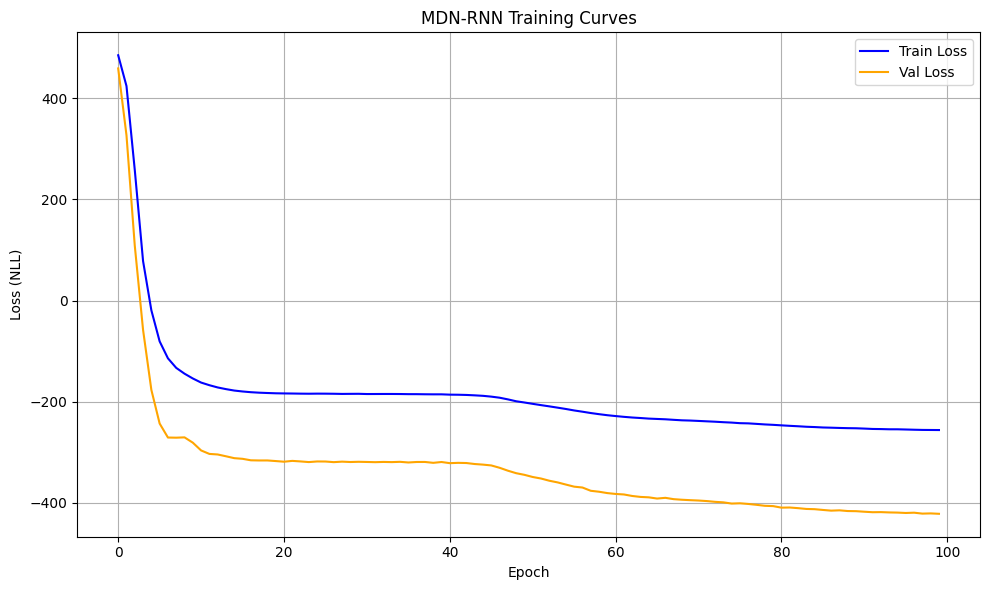

In [10]:
# Training hyperparameters
mdn_learning_rate = 1e-3
mdn_num_epochs = 100

optimizer_mdn = torch.optim.Adam(mdn_rnn.parameters(), lr=mdn_learning_rate)
scheduler_mdn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mdn, mode="min", factor=0.5, patience=5
)

train_losses = []
val_losses = []
best_val_loss = float("inf")

load_mdn = False
mdn_path = OUTPUT_DIR / "mdn_rnn_model.pt"

# Make sure VAE is loaded
if not vae_path.exists():
    print("Missing VAE checkpoint; run the VAE training cell first.")
else:
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("VAE loaded for MDN-RNN training.")

if load_mdn and mdn_path.exists():
    print(f"Loading MDN-RNN from {mdn_path}...")
    mdn_rnn.load_state_dict(torch.load(mdn_path, map_location=device))
    mdn_rnn.eval()
    print("Loaded MDN-RNN.")
else:
    if load_mdn:
        print(f"MDN-RNN checkpoint not found at {mdn_path}; training now.")
    else:
        print("Training MDN-RNN.")

    for epoch in range(mdn_num_epochs):
        # Train
        train_loss = train_mdn_rnn_epoch(
            mdn_rnn, vae, mdn_train_loader, optimizer_mdn, device, latent_shape
        )
        # Evaluate
        val_loss = evaluate_mdn_rnn(mdn_rnn, vae, mdn_test_loader, device, latent_shape)

        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Update learning rate scheduler
        scheduler_mdn.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(mdn_rnn.state_dict(), mdn_path)
            print(
                f"Epoch {epoch + 1}/{mdn_num_epochs} - Saved best model (val_loss: {val_loss:.6f})"
            )

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{mdn_num_epochs}")
            print(f"  Train Loss: {train_loss:.6f}")
            print(f"  Val Loss: {val_loss:.6f}")
            print()

    print("Training completed!")
    print(f"Best validation loss: {best_val_loss:.6f}")

# Plot training curves
if len(train_losses) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(train_losses, label="Train Loss", color="blue")
    ax.plot(val_losses, label="Val Loss", color="orange")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (NLL)")
    ax.set_title("MDN-RNN Training Curves")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "mdn_rnn_training_curves.png", dpi=150, bbox_inches="tight"
    )
    plt.show()
else:
    print("No training history available. Train the model first.")

## Evaluation, Visualizations, and Rollouts

Load saved checkpoints, create prediction figures, and generate rollout movies.


Loading trained models...
Loaded VAE.
Loaded MDN-RNN.

Generating visualizations...


NameError: name 'predict_next_frame' is not defined

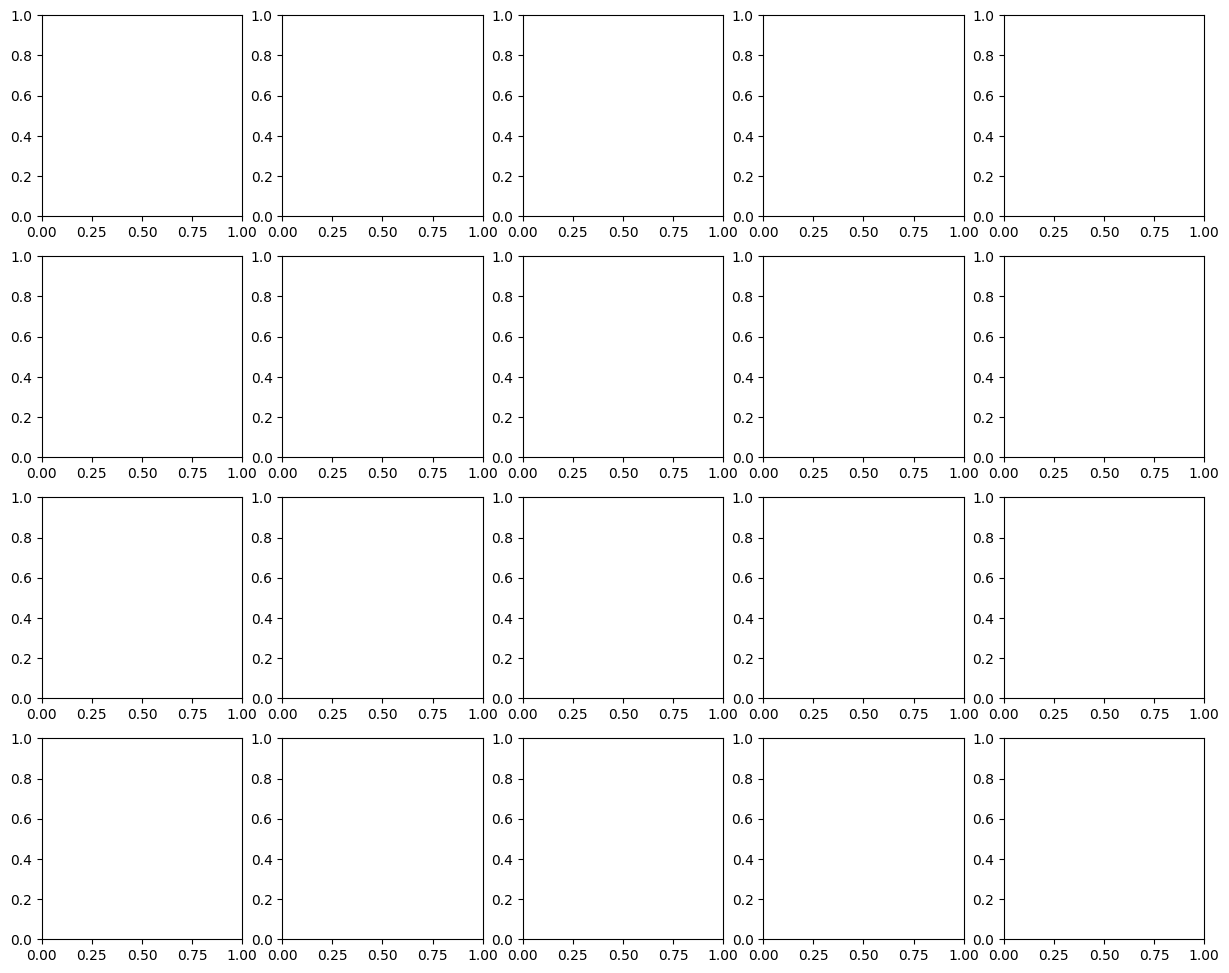

In [11]:
# Load trained models
vae_path = OUTPUT_DIR / "vae_model_mdn_rnn.pt"
mdn_path = OUTPUT_DIR / "mdn_rnn_model.pt"

if vae_path.exists() and mdn_path.exists():
    print(f"Loading trained models...")
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("Loaded VAE.")

    mdn_rnn.load_state_dict(torch.load(mdn_path, map_location=device))
    mdn_rnn.eval()
    print("Loaded MDN-RNN.")

    # Get latent shape
    with torch.no_grad():
        sample_frame = train_dataset.sequences[0][0]
        sample_tensor = torch.from_numpy(sample_frame).float().unsqueeze(0).to(device)
        sample_latent = vae.encode_to_latent(sample_tensor)
        latent_shape = sample_latent.shape

    # Visualize predictions
    print("\nGenerating visualizations...")
    visualize_predictions(
        mdn_rnn,
        vae,
        test_seq_dataset,
        num_samples=4,
        num_context_frames=3,
        device=device,
        latent_shape=latent_shape,
    )
else:
    print("Missing model files; run the training cells first.")
    if not vae_path.exists():
        print(f"  Missing: {vae_path}")
    if not mdn_path.exists():
        print(f"  Missing: {mdn_path}")

In [ ]:
# Generate rollout movie
if vae_path.exists() and mdn_path.exists():
    # Use first sequence from test dataset for rollout
    test_sequence_idx = 0
    test_sequence = test_dataset.sequences[test_sequence_idx]  # [T, C, H, W]

    print(
        f"Using test sequence {test_sequence_idx} with {len(test_sequence)} frames..."
    )

    # Use multiple context frames to properly initialize RNN hidden state
    # This is critical for good predictions - RNN needs context to understand dynamics
    num_context_frames = min(
        30, len(test_sequence) - 1
    )  # Use up to 10 frames, or all available
    print(
        f"Using {num_context_frames} context frames to initialize RNN hidden state..."
    )
    initial_frames = torch.from_numpy(
        test_sequence[:num_context_frames]
    ).float()  # [num_context_frames, C, H, W]

    num_predictions = 50

    # Generate rollout
    rollout = generate_rollout(
        mdn_rnn,
        vae,
        initial_frames,
        num_predictions=num_predictions,
        latent_shape=latent_shape,
        device=device,
    )

    # Get ground truth for comparison (skip context frames since we start from them)
    gt_frames = test_sequence[
        num_context_frames : num_context_frames + num_predictions
    ]  # [num_predictions, C, H, W]

    # Create video frames: [predicted | ground truth]
    print("Creating video frames...")
    video_frames = []
    H, W = test_sequence.shape[2], test_sequence.shape[3]

    for i in range(num_predictions):
        # Rollout contains context frames + predictions, so predictions start at num_context_frames
        pred_frame = rollout[num_context_frames + i]  # [C, H, W]
        if i < len(gt_frames):
            gt_frame = gt_frames[i]  # [C, H, W]
        else:
            gt_frame = np.zeros_like(pred_frame)

        # Convert to RGB for visualization
        if pred_frame.shape[0] == 1:  # Grayscale
            pred_rgb = np.stack([pred_frame[0]] * 3, axis=2)
            gt_rgb = np.stack([gt_frame[0]] * 3, axis=2)
        else:
            pred_rgb = np.transpose(pred_frame, (1, 2, 0))
            gt_rgb = np.transpose(gt_frame, (1, 2, 0))

        # Create composite frame
        composite_frame = np.zeros((H, W * 2, 3), dtype=np.float32)
        composite_frame[:, :W, :] = pred_rgb
        composite_frame[:, W:, :] = gt_rgb

        # Convert to uint8
        composite_frame_uint8 = (np.clip(composite_frame, 0, 1) * 255).astype(np.uint8)
        video_frames.append(composite_frame_uint8)

    # Save video
    output_dir = OUTPUT_DIR / "output_mp4s"
    output_dir.mkdir(exist_ok=True)
    output_filename = (
        output_dir / f"moving_mnist_sequence_{test_sequence_idx}_mdn_rnn_rollout.mp4"
    )

    print(f"Saving video to {output_filename}...")
    imageio.mimwrite(
        str(output_filename), video_frames, fps=10, codec="libx264", quality=8
    )
    print(f"Saved video to {output_filename}")
else:
    print("Missing model files; run the training cells first.")

In [ ]:
# Generate rollout movie for training sequence
if vae_path.exists() and mdn_path.exists():
    # Use first sequence from training dataset for rollout
    train_sequence_idx = 0
    train_sequence = train_dataset.sequences[train_sequence_idx]  # [T, C, H, W]

    print(
        f"Using training sequence {train_sequence_idx} with {len(train_sequence)} frames..."
    )

    # Use multiple context frames to properly initialize RNN hidden state
    # This is critical for good predictions - RNN needs context to understand dynamics
    num_context_frames = min(
        30, len(train_sequence) - 1
    )  # Use up to 10 frames, or all available
    print(
        f"Using {num_context_frames} context frames to initialize RNN hidden state..."
    )
    initial_frames = torch.from_numpy(
        train_sequence[:num_context_frames]
    ).float()  # [num_context_frames, C, H, W]

    num_predictions = 50

    # Generate rollout
    rollout = generate_rollout(
        mdn_rnn,
        vae,
        initial_frames,
        num_predictions=num_predictions,
        latent_shape=latent_shape,
        device=device,
    )

    # Get ground truth for comparison (skip context frames since we start from them)
    gt_frames = train_sequence[
        num_context_frames : num_context_frames + num_predictions
    ]  # [num_predictions, C, H, W]

    # Create video frames: [predicted | ground truth]
    print("Creating video frames...")
    video_frames = []
    H, W = train_sequence.shape[2], train_sequence.shape[3]

    for i in range(num_predictions):
        # Rollout contains context frames + predictions, so predictions start at num_context_frames
        pred_frame = rollout[num_context_frames + i]  # [C, H, W]
        if i < len(gt_frames):
            gt_frame = gt_frames[i]  # [C, H, W]
        else:
            gt_frame = np.zeros_like(pred_frame)

        # Convert to RGB for visualization
        if pred_frame.shape[0] == 1:  # Grayscale
            pred_rgb = np.stack([pred_frame[0]] * 3, axis=2)
            gt_rgb = np.stack([gt_frame[0]] * 3, axis=2)
        else:
            pred_rgb = np.transpose(pred_frame, (1, 2, 0))
            gt_rgb = np.transpose(gt_frame, (1, 2, 0))

        # Create composite frame
        composite_frame = np.zeros((H, W * 2, 3), dtype=np.float32)
        composite_frame[:, :W, :] = pred_rgb
        composite_frame[:, W:, :] = gt_rgb

        # Convert to uint8
        composite_frame_uint8 = (np.clip(composite_frame, 0, 1) * 255).astype(np.uint8)
        video_frames.append(composite_frame_uint8)

    # Save video
    output_dir = OUTPUT_DIR / "output_mp4s"
    output_dir.mkdir(exist_ok=True)
    output_filename = (
        output_dir
        / f"moving_mnist_train_sequence_{train_sequence_idx}_mdn_rnn_rollout.mp4"
    )

    print(f"Saving video to {output_filename}...")
    imageio.mimwrite(
        str(output_filename), video_frames, fps=10, codec="libx264", quality=8
    )
    print(f"Saved video to {output_filename}")
else:
    print("Missing model files; run the training cells first.")